# **PART B – ANN for Classification (Breast Cancer Dataset)**

**Import Libraries**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("NAME:    Arunagiri R")
print("ROLL NO: 24BAD013")

NAME:    Arunagiri R
ROLL NO: 24BAD013


**Load Breast Cancer Dataset**

In [12]:
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer dataset
data = load_breast_cancer()

# Features (Input)
X = data.data

# Target (Output)
y = data.target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (569, 30)
Target Shape: (569,)


**Split into Training and Testing Sets**

In [13]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Standardize the Features**

In [14]:
# Create the StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test = scaler.transform(X_test)

**Build ANN Model**

In [15]:
# Create the ANN model
model = Sequential([
    Dense(16, activation='relu', input_shape=(30,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Compile the Model**

In [16]:
# Compile the ANN model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**Train the Model**

In [17]:
# Train the ANN model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.7857 - loss: 0.5627 - val_accuracy: 0.8462 - val_loss: 0.5241
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8819 - loss: 0.5065 - val_accuracy: 0.8571 - val_loss: 0.4786
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9066 - loss: 0.4571 - val_accuracy: 0.9011 - val_loss: 0.4313
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9011 - loss: 0.4097 - val_accuracy: 0.9121 - val_loss: 0.3816
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9121 - loss: 0.3612 - val_accuracy: 0.9451 - val_loss: 0.3315
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.9258 - loss: 0.3114 - val_accuracy: 0.9670 - val_loss: 0.2826
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9341 - loss: 0.2629 - val_accuracy: 0.9670 - val_loss: 0.2364
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9560 - loss: 0.2183 - val_accuracy: 0.9670 - v

**Predict Labels**

In [18]:
# Predict probabilities for the test data
y_pred = model.predict(X_test)

# Convert probabilities into class labels (0 or 1)
y_pred = (y_pred > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


**Evaluation Metrics**

Accuracy : 0.98
Precision: 0.97
Recall   : 1.0
F1-Score : 0.99


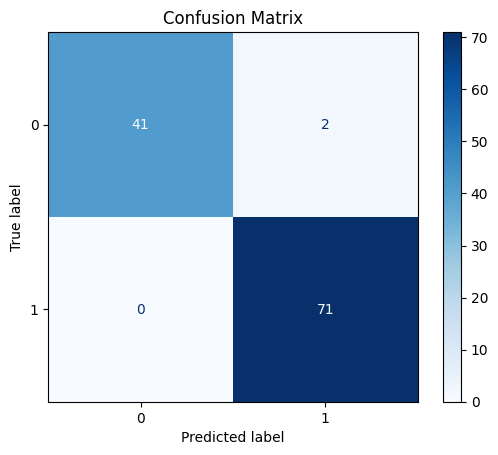

In [19]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print the metrics
print("Accuracy :", round(accuracy, 2))
print("Precision:", round(precision, 2))
print("Recall   :", round(recall, 2))
print("F1-Score :", round(f1, 2))

# Display the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

**Visualization**

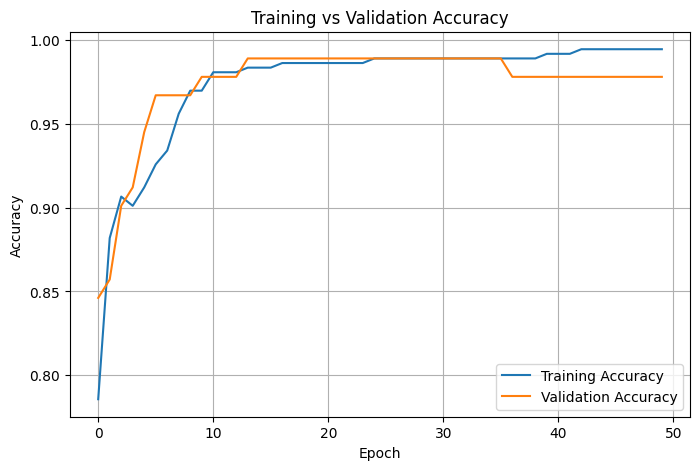

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()